In [34]:
#Time Series Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
#Find available dataset names in seaborn
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [36]:
df = sns.load_dataset('flights')
print(df.head)
print(df.tail)

<bound method NDFrame.head of      year month  passengers
0    1949   Jan         112
1    1949   Feb         118
2    1949   Mar         132
3    1949   Apr         129
4    1949   May         121
..    ...   ...         ...
139  1960   Aug         606
140  1960   Sep         508
141  1960   Oct         461
142  1960   Nov         390
143  1960   Dec         432

[144 rows x 3 columns]>
<bound method NDFrame.tail of      year month  passengers
0    1949   Jan         112
1    1949   Feb         118
2    1949   Mar         132
3    1949   Apr         129
4    1949   May         121
..    ...   ...         ...
139  1960   Aug         606
140  1960   Sep         508
141  1960   Oct         461
142  1960   Nov         390
143  1960   Dec         432

[144 rows x 3 columns]>


In [37]:
#we get only year and month for the date, we need day als
#Convert the date to a yyyy-mm-dd format in a new column named yearMonth
df['yearMonth'] = "01-"+df['month'].astype(str)+"-"+df['year'].astype(str)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
 3   yearMonth   144 non-null    object  
dtypes: category(1), int64(2), object(1)
memory usage: 4.0+ KB
None


In [38]:
#The new yearMonth column is of type "object" (i.e string) - we need it in the date format
df['yearMonth'] = pd.to_datetime(df['yearMonth'])
print(df.info())
print(df.head)
print(df.tail)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   year        144 non-null    int64         
 1   month       144 non-null    category      
 2   passengers  144 non-null    int64         
 3   yearMonth   144 non-null    datetime64[ns]
dtypes: category(1), datetime64[ns](1), int64(2)
memory usage: 4.0 KB
None
<bound method NDFrame.head of      year month  passengers  yearMonth
0    1949   Jan         112 1949-01-01
1    1949   Feb         118 1949-02-01
2    1949   Mar         132 1949-03-01
3    1949   Apr         129 1949-04-01
4    1949   May         121 1949-05-01
..    ...   ...         ...        ...
139  1960   Aug         606 1960-08-01
140  1960   Sep         508 1960-09-01
141  1960   Oct         461 1960-10-01
142  1960   Nov         390 1960-11-01
143  1960   Dec         432 1960-12-01

[144 rows x 4 columns]>
<bound met

In [39]:
df.set_index('yearMonth',inplace = True)      #inplace will make the change permanent to the DF
print(df.head())

            year month  passengers
yearMonth                         
1949-01-01  1949   Jan         112
1949-02-01  1949   Feb         118
1949-03-01  1949   Mar         132
1949-04-01  1949   Apr         129
1949-05-01  1949   May         121


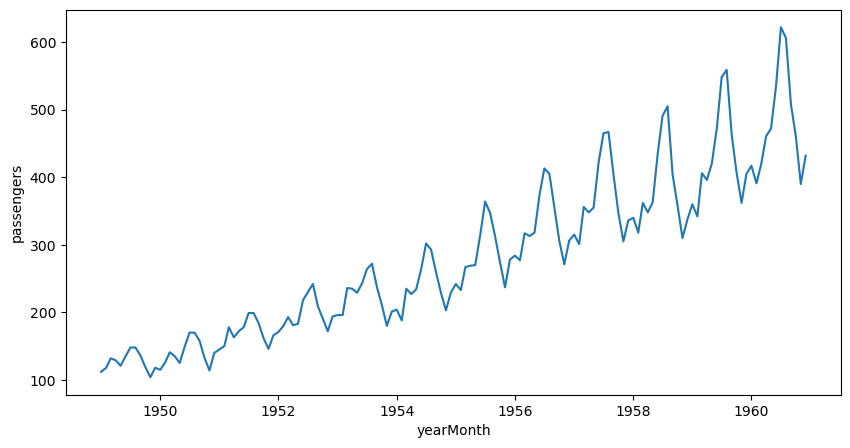

In [40]:
#Visualize the time series
plt.figure(figsize=(10,5))
sns.lineplot(data = df, x=df.index, y=df.passengers)
plt.show()

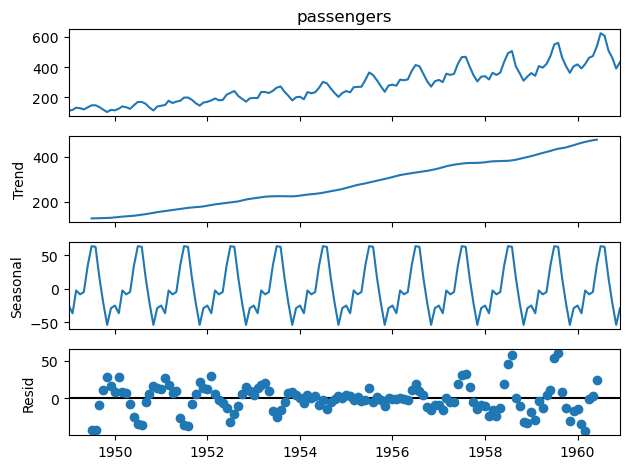

In [41]:
#Check further for seasonality and trend by doing decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df.passengers, period =12)
fig =decomposition.plot()
plt.show()

In [42]:
#to check stationary
#rolling mean and std devfor 12 months
df['rollMean'] = df.passengers.rolling(window =12).mean()
df['rollStd'] = df.passengers.rolling(window = 12).std()


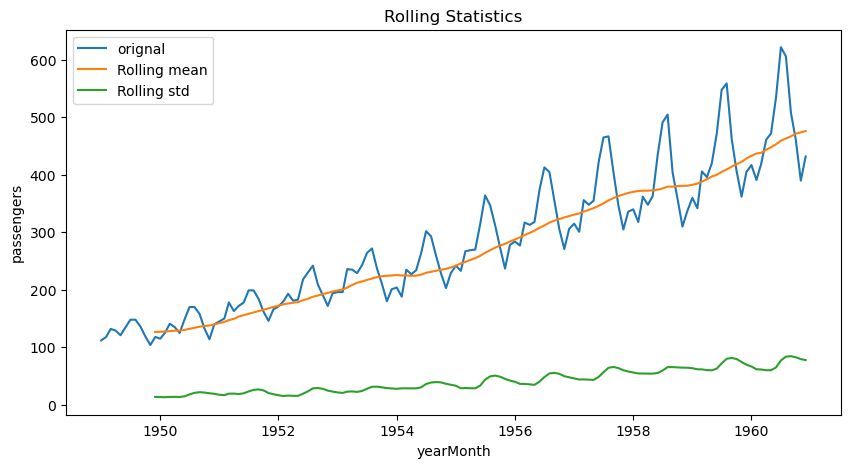

In [43]:
#plot orignal serires withrolling mean and std dev
plt.figure(figsize=(10,5))
sns.lineplot(data=df,x=df.index, y = df.passengers, label="orignal")
sns.lineplot(data=df,x=df.index, y = df.rollMean, label="Rolling mean")
sns.lineplot(data=df,x=df.index, y = df.rollStd, label="Rolling std")
plt.title("Rolling Statistics")
plt.show()

A time series is stationary if the rolling mean and rolling std are in a straight like line. 
1) mean is Not a straight line, 2)std deviation is in a straight line, Thus our time series is Not stationary.

ADF p-value: 0.9919
The time series is not stationary (fail to reject H0).


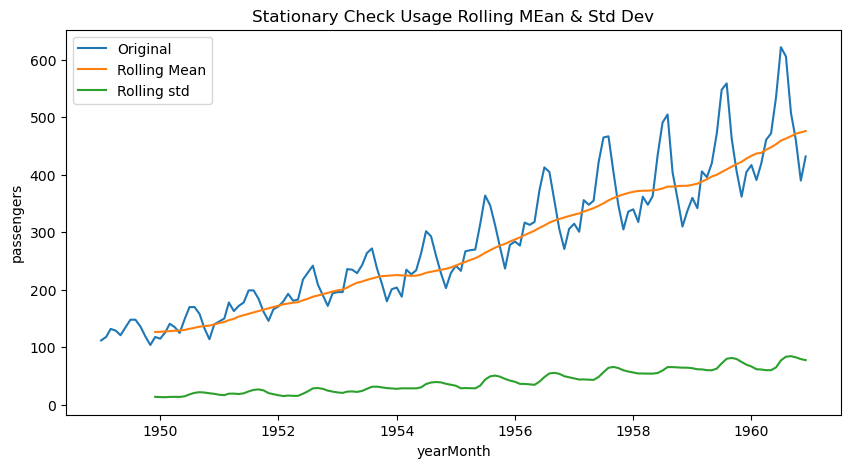

In [44]:
#define the function for stationary check
def test_stationary(dataFrame, var):
    dataFrame['rollMean'] = dataFrame[var].rolling(window=12).mean()
    dataFrame['rollStd'] = dataFrame[var].rolling(window=12).std()

    from statsmodels.tsa.stattools import adfuller
    adf_result = adfuller(dataFrame[var])
    p_value = adf_result[1]

    print(f"ADF p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("The time series is stationary(reject H0).")
    else:
        print("The time series is not stationary (fail to reject H0).")

    #plot
    plt.figure(figsize=(10,5))
    sns.lineplot(data=dataFrame, x=dataFrame.index, y=var, label='Original')
    sns.lineplot(data=dataFrame, x=dataFrame.index, y='rollMean',label='Rolling Mean')
    sns.lineplot(data=dataFrame, x=dataFrame.index, y='rollStd', label='Rolling std')
    plt.title("Stationary Check Usage Rolling MEan & Std Dev")
    plt.legend()
    plt.show()

#calling the function to test functionality
test_stationary(df,'passengers')

            passengers  shift  shiftDiff
yearMonth                               
1949-01-01         112    NaN        NaN
1949-02-01         118  112.0        6.0
1949-03-01         132  118.0       14.0
1949-04-01         129  132.0       -3.0
1949-05-01         121  129.0       -8.0
1949-06-01         135  121.0       14.0
1949-07-01         148  135.0       13.0
1949-08-01         148  148.0        0.0
1949-09-01         136  148.0      -12.0
1949-10-01         119  136.0      -17.0
1949-11-01         104  119.0      -15.0
1949-12-01         118  104.0       14.0
1950-01-01         115  118.0       -3.0
1950-02-01         126  115.0       11.0
1950-03-01         141  126.0       15.0
1950-04-01         135  141.0       -6.0
1950-05-01         125  135.0      -10.0
1950-06-01         149  125.0       24.0
1950-07-01         170  149.0       21.0
1950-08-01         170  170.0        0.0
ADF p-value: 0.0542
The time series is not stationary (fail to reject H0).


C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_11032\1981570927.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollMean'] = dataFrame[var].rolling(window=12).mean()
C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_11032\1981570927.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollStd'] = dataFrame[var].rolling(window=12).std()


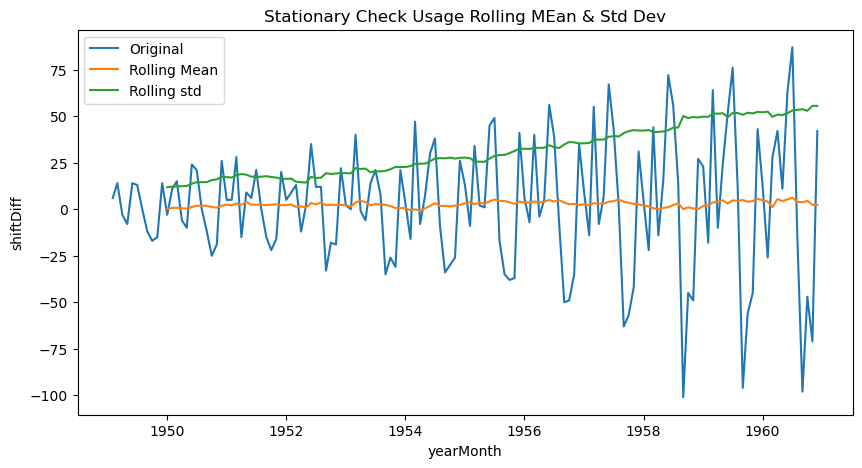

In [45]:
air_df = df[['passengers']].copy()
#Try shift diff of 1
air_df['shift'] = air_df.passengers.shift(1)
air_df['shiftDiff'] = air_df['passengers'] - air_df['shift']
print(air_df.head(20))
#Test stationarity
test_stationary(air_df.dropna(),'shiftDiff')

            passengers  shift  shiftDiff  shift2  shiftDiff2
yearMonth                                                   
1949-01-01         112    NaN        NaN     NaN         NaN
1949-02-01         118  112.0        6.0     NaN         NaN
1949-03-01         132  118.0       14.0   112.0        20.0
1949-04-01         129  132.0       -3.0   118.0        11.0
1949-05-01         121  129.0       -8.0   132.0       -11.0
1949-06-01         135  121.0       14.0   129.0         6.0
1949-07-01         148  135.0       13.0   121.0        27.0
1949-08-01         148  148.0        0.0   135.0        13.0
1949-09-01         136  148.0      -12.0   148.0       -12.0
1949-10-01         119  136.0      -17.0   148.0       -29.0
1949-11-01         104  119.0      -15.0   136.0       -32.0
1949-12-01         118  104.0       14.0   119.0        -1.0
1950-01-01         115  118.0       -3.0   104.0        11.0
1950-02-01         126  115.0       11.0   118.0         8.0
1950-03-01         141  

C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_11032\1981570927.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollMean'] = dataFrame[var].rolling(window=12).mean()
C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_11032\1981570927.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollStd'] = dataFrame[var].rolling(window=12).std()


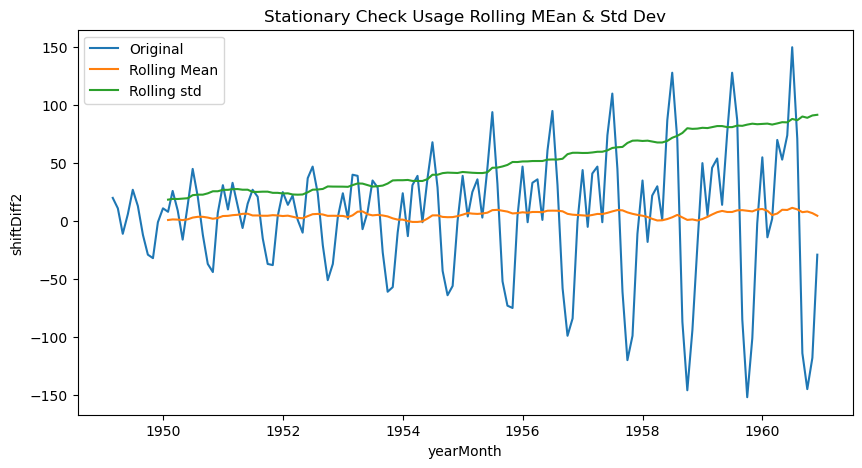

In [46]:
#p-value is still >0.05, so we cannot reject h0.. lets try shift of 2

air_df['shift2'] = air_df.passengers.shift(2)
air_df['shiftDiff2'] = air_df['passengers'] - air_df['shift2']
print(air_df.head(20))
#Test stationarity
test_stationary(air_df.dropna(),'shiftDiff2')
#Conclusion : The data has become somewhat stationary

1.0


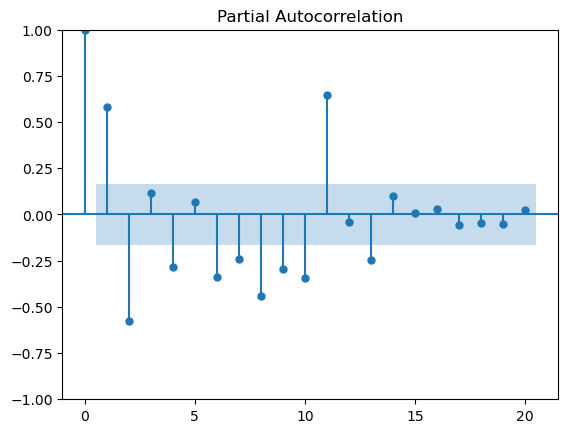

In [47]:
#Now ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
corr_value = air_df['passengers'].corr(air_df['passengers'])
print(corr_value)
plot_pacf(air_df['shiftDiff2'].dropna(),lags=20)
plt.show()

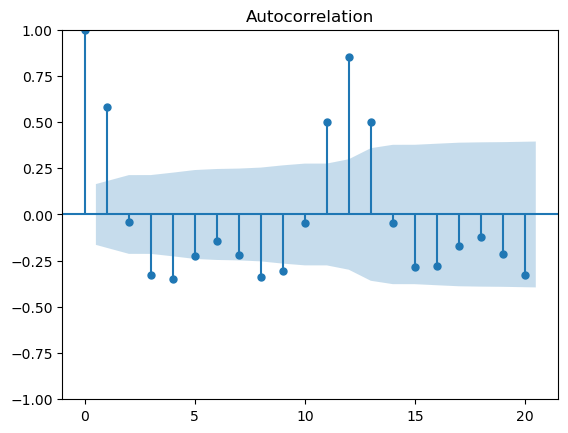

In [48]:
#Now let us take this value as p =1 and find q for  which we need ACF
plot_acf(air_df['shiftDiff2'].dropna(), lags =20)
plt.show()

In [49]:
#Build Arima model
train = air_df[:round(len(air_df)*70/100)]  #take the first 70% data
print(train.head()) #just to check where it starts

test = air_df[round(len(air_df)*71/100):] #Take the last 30% of data starting from 71%
print(test.head())


model = ARIMA(train['passengers'], order =(1,2,1)) #Parameters: p,d,q
model_fit =model.fit()
prediction = model_fit.predict(start = test.index[0], end = test.index[-1])
air_df['arimaPred'] = prediction
print(air_df.tail())

            passengers  shift  shiftDiff  shift2  shiftDiff2
yearMonth                                                   
1949-01-01         112    NaN        NaN     NaN         NaN
1949-02-01         118  112.0        6.0     NaN         NaN
1949-03-01         132  118.0       14.0   112.0        20.0
1949-04-01         129  132.0       -3.0   118.0        11.0
1949-05-01         121  129.0       -8.0   132.0       -11.0
            passengers  shift  shiftDiff  shift2  shiftDiff2
yearMonth                                                   
1957-07-01         465  422.0       43.0   355.0       110.0
1957-08-01         467  465.0        2.0   422.0        45.0
1957-09-01         404  467.0      -63.0   465.0       -61.0
1957-10-01         347  404.0      -57.0   467.0      -120.0
1957-11-01         305  347.0      -42.0   404.0       -99.0
            passengers  shift  shiftDiff  shift2  shiftDiff2   arimaPred
yearMonth                                                               


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [50]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train['passengers'],order=(1,2,1), seasonal_order=(1,2,1,12))
model_fit = model.fit()
prediction = model_fit.predict(start=test.index[0], end =test.index[-1])
air_df['sarimaxPred'] = prediction
print(air_df.tail())

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            passengers  shift  shiftDiff  shift2  shiftDiff2   arimaPred  \
yearMonth                                                                  
1960-08-01         606  622.0      -16.0   535.0        71.0  451.951946   
1960-09-01         508  606.0      -98.0   622.0      -114.0  454.405309   
1960-10-01         461  508.0      -47.0   606.0      -145.0  456.858672   
1960-11-01         390  461.0      -71.0   508.0      -118.0  459.312036   
1960-12-01         432  390.0       42.0   461.0       -29.0  461.765399   

            sarimaxPred  
yearMonth                
1960-08-01   588.760533  
1960-09-01   518.375287  
1960-10-01   452.601758  
1960-11-01   402.822019  
1960-12-01   450.800841  


            passengers  shift  shiftDiff  shift2  shiftDiff2  arimaPred  \
yearMonth                                                                 
1949-01-01         112    NaN        NaN     NaN         NaN        NaN   
1949-02-01         118  112.0        6.0     NaN         NaN        NaN   
1949-03-01         132  118.0       14.0   112.0        20.0        NaN   
1949-04-01         129  132.0       -3.0   118.0        11.0        NaN   
1949-05-01         121  129.0       -8.0   132.0       -11.0        NaN   

            sarimaxPred  
yearMonth                
1949-01-01          NaN  
1949-02-01          NaN  
1949-03-01          NaN  
1949-04-01          NaN  
1949-05-01          NaN  


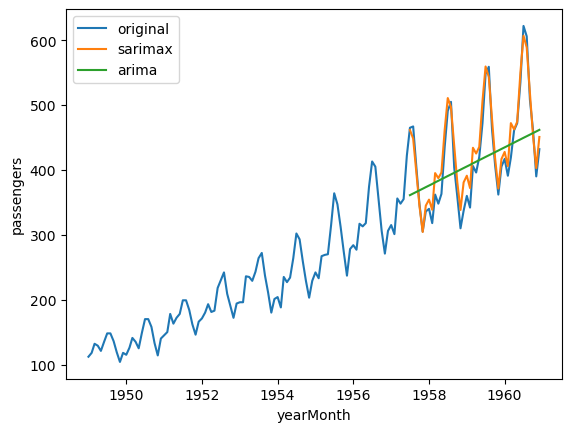

In [51]:
#plot
air_df.dropna()
print(air_df.head())
sns.lineplot(data=air_df, x=air_df.index, y ="passengers", label = "original")
sns.lineplot(data=air_df, x=air_df.index, y='sarimaxPred',label ="sarimax")
sns.lineplot(data=air_df, x=air_df.index, y='arimaPred', label = "arima")
plt.show()
#SARIMAX predictions are much more accurate


In [52]:
#Future Prediction
#First check the laste date in our dataset
print(air_df.tail())

            passengers  shift  shiftDiff  shift2  shiftDiff2   arimaPred  \
yearMonth                                                                  
1960-08-01         606  622.0      -16.0   535.0        71.0  451.951946   
1960-09-01         508  606.0      -98.0   622.0      -114.0  454.405309   
1960-10-01         461  508.0      -47.0   606.0      -145.0  456.858672   
1960-11-01         390  461.0      -71.0   508.0      -118.0  459.312036   
1960-12-01         432  390.0       42.0   461.0       -29.0  461.765399   

            sarimaxPred  
yearMonth                
1960-08-01   588.760533  
1960-09-01   518.375287  
1960-10-01   452.601758  
1960-11-01   402.822019  
1960-12-01   450.800841  


In [53]:
#MS: Month start Frequency
#Create a dataframe to hold index values from 01.01.1961 to 01.12.1962
futureDate = pd.DataFrame(pd.date_range(start="1961-01-01", end="1962-12-01", freq="MS"),columns=["Dates"])
futureDate.set_index("Dates", inplace=True)
print(futureDate.head())

Empty DataFrame
Columns: []
Index: [1961-01-01 00:00:00, 1961-02-01 00:00:00, 1961-03-01 00:00:00, 1961-04-01 00:00:00, 1961-05-01 00:00:00]


1961-01-01    462.565962
1961-02-01    437.557870
1961-03-01    508.355576
1961-04-01    497.735506
1961-05-01    511.039378
1961-06-01    591.679377
1961-07-01    652.339786
1961-08-01    632.031906
1961-09-01    555.854281
1961-10-01    485.356773
1961-11-01    432.003585
1961-12-01    482.568259
1962-01-01    494.969468
1962-02-01    466.811541
1962-03-01    541.960407
1962-04-01    530.334689
1962-05-01    545.060879
1962-06-01    630.744732
1962-07-01    694.857126
1962-08-01    672.406481
1962-09-01    590.336646
1962-10-01    515.025648
1962-11-01    458.050182
1962-12-01    511.103196
Freq: MS, Name: predicted_mean, dtype: float64


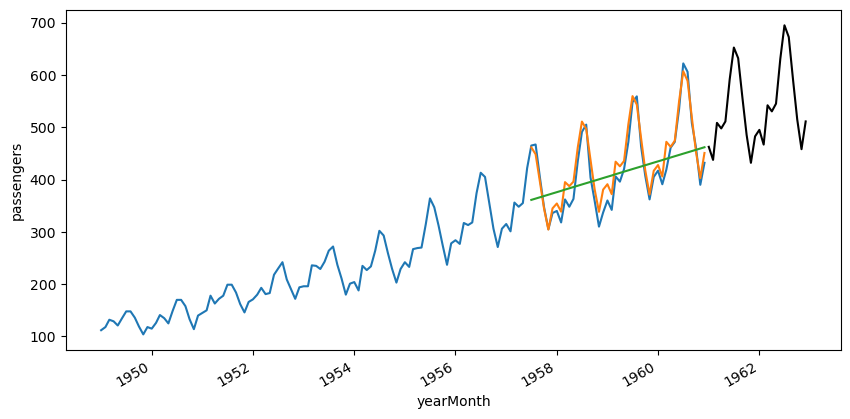

In [54]:
#predict and print
print(model_fit.predict(start=futureDate.index[0], end=futureDate.index[-1]))

#plot
air_df.dropna()
plt.figure(figsize=(10,5))
sns.lineplot(data=air_df, x=air_df.index, y="passengers")
sns.lineplot(data=air_df, x=air_df.index, y="sarimaxPred")
sns.lineplot(data=air_df, x=air_df.index, y="arimaPred")
model_fit.predict(start=futureDate.index[0], end=futureDate.index[-1]).plot(color="black")
plt.show()

In [55]:
#Model evaluation
air_df = air_df.dropna()
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

#arima evaluation
mae = mean_absolute_error(air_df["passengers"],air_df["arimaPred"])
rmse = root_mean_squared_error(air_df["passengers"],air_df["arimaPred"])
r2 = r2_score(air_df["passengers"], air_df["arimaPred"])
print(f"ARIMA MAE: {mae}, RMSE : {rmse}, R^2: {r2}")

ARIMA MAE: 55.18507066792935, RMSE : 69.13741193092274, R^2: 0.20545486532650503


In [56]:
#sarimax evaluation
mae = mean_absolute_error(air_df["passengers"],air_df["sarimaxPred"])
rmse = root_mean_squared_error(air_df["passengers"],air_df["sarimaxPred"])
r2 = r2_score(air_df["passengers"], air_df["sarimaxPred"])
print(f"ARIMA MAE: {mae}, RMSE : {rmse},R^2: {r2}")

ARIMA MAE: 18.751463814718086, RMSE : 22.27089869418277,R^2: 0.91755433583807
